

## <span style="color:#4375c7">Data and AI in Economics</span>
***
*The course material is for educational purposes only. Nothing herein should be taken as an investment advice or  offers any opinion  <br/> with respect to the suitability of any security. To obtain further information about this course, [contact us](http://wp.firrm.de/) or visit us during [office hours](https://www.finance.wiwi.tu-dortmund.de/cms/index.php/homepage/kalender).*
***


## Causal Inference


## 2. Hands-on session <a id='ho'></a>

### Exercise 1
The following exercise is based on a (real-world) example by Allen Downey to demonstrate Simpson's Paradox.

In 2021, a journalist (The Atlantic magazine identified him as "The Pandemic's Wrongest Man") wrote a series of misleading articles about the COVID pandemic. In November, this journalist posted an online newsletter with the title "Vaccinated English adults under 60 are dying at twice the rate of unvaccinated people the same age". It includes a graph showing that the overall death rate among young, vaccinated people increased between April and September, 2021, and was actually higher among the vaccinated than among the unvaccinated.

As you might expect, this newsletter got a lot of attention. Among skeptics, it seemed like proof that vaccines were not just ineffective, but harmful. And among people who were counting on vaccines to end the pandemic, it seemed like a devastating setback.

Many people fact-checked the article, and at first the results held up to scrutiny: the graph accurately represented data published by the U.K. Office for National Statistics. Specifically, it showed death rates, from any cause, for people in England between 10 and 59 years old, from March to September 2021. And between April and September, these rates were higher among the fully vaccinated, compared to the unvaccinated, by a factor of almost 2. So the journalist's description of the results was correct.

However, his conclusion that vaccines were causing increased mortality was completely wrong. In fact, the data he reported shows that vaccines were safe and effective in this population, and demonstrably saved many lives.

How, you might ask, can increased mortality be evidence of saved lives? The answer is Simpson's paradox.

Let's look at the data and disenchant what the original article suggested.

1. [This link](https://substackcdn.com/image/fetch/f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fbucketeer-e05bbc84-baa3-437e-9518-adb32be77984.s3.amazonaws.com%2Fpublic%2Fimages%2Fbdca5329-b20b-4518-a733-fff84cc22124_1098x681.png) features the graph that was presented in the article. Use the dataset "datasetfinalcorrected3.xlsx" from the [U.K. Office for National Statistics](https://www.ons.gov.uk/file?uri=/peoplepopulationandcommunity/birthsdeathsandmarriages/deaths/datasets/deathsbyvaccinationstatusengland/deathsoccurringbetween2januaryand24september2021/datasetfinalcorrected3.xlsx) to replicate the graph, beginning on 19 March 2021!
<br>
2. The journalist concludes: "Vaccinated people under 60 are twice as likely to die as unvaccinated people. And overall deaths in Britain are running well above normal. I don't know how to explain this other than vaccine-caused mortality." Did you realize, when replicating his graph, what has paved the way for this wrongful conclusion?
<br>
3. Now, use the whole available time range (1 January - 30 September 2021) and show the same graph for the other age groups as well!
<br>
4. So what explains the apparent reversal among people between 10 and 59 years old? Simpson's Paradox! And what are the particular causes of Simpson's Paradox within this age group?
<br>
5. We will look at the data more carefully by following an analysis by epidemiologist Jeffrey Morris, who refuted the unreliable journalist's claims within days of their publication. He divides the excessively wide 10-59 year age group into 10 groups, each 5 years wide.
<br>
To estimate normal, pre-pandemic death rates in these groups, he uses 2019 data from the U.K. Office of National Statistics. To estimate the vaccination rate in each group, he uses data from the coronavirus dashboard provided by the U.K. Health Security Agency. Finally, to estimate the fraction of people in each age group, he uses data from a web site called PopulationPyramid, which organizes and publishes data from the United Nations Department of Economic and Social Affairs. Not to get lost in the details, these are all reliable data sources.
<br>
We want to compute the distribution of ages in the vaccinated and unvaccinated groups at the beginning of August 2021 (choosing a point near the middle of the interval in the original graph). Calculate the share of people per age group of the 10-59 year old, the share of vaccinated people per age group and the share of unvaccinated people per age group! Plot the share of vaccinated and unvaccinated along the age groups and comment!
<br>
6. Now, for the sake of this example, let's imagine that there are no deaths due to COVID, and no deaths due to the vaccine. Based only on the distribution of ages and the death rates from 2019, compute the expected death rates for the vaccinated and unvaccinated groups!
<br>
7. So far we have used only data that was publicly available in November 2021, but if we take advantage of more recent data, we can get a clearer picture of what was happening then and what has happened since. In more recent reports, data from the U.K. Office of National Statistics are broken into smaller age groups. Instead of one group from ages 10 to 59, we have three groups from 18 to 39, 40 to 49, and 50 to 59. Use the dataset "referencetable20220516accessiblecorrected.xlsx" from the [U.K. Office for National Statistics](https://www.ons.gov.uk/file?uri=/peoplepopulationandcommunity/birthsdeathsandmarriages/deaths/datasets/deathsbyvaccinationstatusengland/deathsoccurringbetween1january2021and31march2022/referencetable20220516accessiblecorrected.xlsx) to show similar plots as in task 3!
***

In [1]:
## task 1
!pip install -r https://raw.githubusercontent.com/firrm/DAI/main/requirements.txt #ensure that the required packages are installed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Ignoring appnope: markers 'sys_platform == "darwin"' don't match your environment
Ignoring colorama: markers 'os_name == "nt" or sys_platform == "win32"' don't match your environment


Ignoring pywin32-ctypes: markers 'sys_platform == "win32"' don't match your environment
Ignoring pywinpty: markers 'os_name == "nt"' don't match your environment
Ignoring scipy: markers 'python_full_version >= "3.13"' don't match your environment
Ignoring xattr: markers 'sys_platform == "darwin"' don't match your environment



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
filename = "https://raw.githubusercontent.com/firrm/DAI/main/data/datasetfinalcorrected3.xlsx"
df = pd.read_excel(
    filename,
    sheet_name="Table 4",
    skiprows=3,
    skipfooter=12,
)
df.tail()

,Week ending,Week number,Vaccination status,Age group,Number of deaths,Population,Percentage of total age-group population,"Age-specific rate per 100,000",Unnamed: 8,Lower confidence limit,Upper confidence limit
603,2021-09-17,37,Second dose,80+,4000,2437192,96.3,164.1,NaN,159.1,169.3
604,2021-09-24,38,Second dose,10-59,400,17924346,66.4,2.2,NaN,2,2.5
605,2021-09-24,38,Second dose,60-69,638,4973647,93.8,12.8,NaN,11.9,13.9
606,2021-09-24,38,Second dose,70-79,1553,4171936,96.3,37.2,NaN,35.4,39.1
607,2021-09-24,38,Second dose,80+,3839,2439328,96.3,157.4,NaN,152.4,162.4


In [3]:
df["Age-specific rate per 100,000"].replace(":", np.nan, inplace=True)

/tmp/ipykernel_458374/4056399107.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age-specific rate per 100,000"].replace(":", np.nan, inplace=True)
/tmp/ipykernel_458374/4056399107.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Age-specific rate per 100,000"].replace(":", np.nan, in

In [4]:
df.columns

Index(['Week ending', 'Week number', 'Vaccination status', 'Age group',
       'Number of deaths', 'Population',
       'Percentage of total age-group population',
       'Age-specific rate per 100,000', 'Unnamed: 8', 'Lower confidence limit',
       'Upper confidence limit'],
      dtype='object')

In [5]:
table = df.pivot_table(
    index="Week ending",
    columns=["Vaccination status", "Age group"],
    values="Age-specific rate per 100,000",
    aggfunc="median",
)
table.head()

Vaccination status 21 days or more after first dose                      \
Age group                                     10-59 60-69  70-79    80+   
Week ending                                                               
2021-01-08                                      NaN   NaN    NaN  190.1   
2021-01-15                                      2.7   NaN  104.3  186.8   
2021-01-22                                      2.0   7.5  107.2  175.7   
2021-01-29                                      2.3  14.4   65.0  152.3   
2021-02-05                                      1.5  15.0   59.9  157.5   

Vaccination status Second dose                   Unvaccinated               \
Age group                10-59 60-69 70-79   80+        10-59 60-69  70-79   
Week ending                                                                  
2021-01-08                 NaN   NaN   NaN   8.1          3.7  27.3   69.8   
2021-01-15                 NaN   NaN   NaN  32.8          4.0  30.1   78.8   
2021-01-22                 NaN   NaN   NaN  52.8          4.1  30.8   95.5   
2021-01-29                 NaN   NaN   NaN  53.4          3.7  29.2  112.2   
2021-02-05                 NaN   NaN   NaN  64.7          3.6  26.5  168.2   

Vaccination status         Within 21 days of first dose                     
Age group              80+                        10-59 60-69 70-79    80+  
Week ending                                                                 
2021-01-08           413.4                          0.7  10.8  32.6   84.5  
2021-01-15           645.1                          1.9  19.7  25.8  100.6  
2021-01-22          1198.0                          1.7  21.5  25.4  122.0  
2021-01-29          1571.9                          1.8  18.3  26.3  180.9  
2021-02-05          1456.1                          3.4  11.9  22.8  223.0

In [6]:
## task 5

index = [
    "10-14",
    "15-19",
    "20-24",
    "25-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
]
rate = [8.8, 23.1, 39.1, 48.4, 66.9, 97.3, 143.3, 219.6, 321.5, 478.2]
pct_vax = [0, 26.7, 59.6, 59.7, 63.3, 63.3, 74.6, 80.5, 85.6, 88.2]
pct_pop = [5.9, 5.5, 6.2, 6.8, 6.7, 6.6, 6.0, 6.6, 7.0, 6.6]

sheet = pd.DataFrame(dict(rate=rate, pct_vax=pct_vax, pct_pop=pct_pop), index)

In [7]:
## task 7

filename = "https://raw.githubusercontent.com/firrm/DAI/main/data/referencetable20220516accessiblecorrected.xlsx"
df = pd.read_excel(
    filename,
    sheet_name="Table 2",
    skiprows=3,
)
df.tail()

,Cause of Death,Year,Month,Age group,Vaccination status,Count of deaths,Person-years,"Age-standardised mortality rate / 100,000 person-years",Noted as Unreliable,Lower confidence limit,Upper confidence limit
2200,Non-COVID-19 deaths,2022,March,90+,"First dose, at least 21 days ago",57,191,29817.6,NaN,22582.1,38633
2201,Non-COVID-19 deaths,2022,March,90+,"Second dose, less than 21 days ago",<3,7,x,NaN,x,x
2202,Non-COVID-19 deaths,2022,March,90+,"Second dose, at least 21 days ago",515,1415,36402.2,NaN,33325.7,39686.4
2203,Non-COVID-19 deaths,2022,March,90+,"Third dose or booster, less than 21 days ago",20,67,29992.6,NaN,18312.4,46323.7
2204,Non-COVID-19 deaths,2022,March,90+,"Third dose or booster, at least 21 days ago",7024,36170,19419.5,NaN,18967.9,19879


In [8]:
df["date"] = pd.to_datetime(df["Year"].astype(str) + " " + df["Month"])
rate = "Age-standardised mortality rate / 100,000 person-years"
df["rate"] = df[rate].replace("x", np.nan) / 52
count = "Count of deaths"
df[count].replace("<3", np.nan, inplace=True)
all_cause = df["Cause of Death"] == "All causes"
all_cause_df = df[all_cause]

/tmp/ipykernel_458374/391369865.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["Year"].astype(str) + " " + df["Month"])
/tmp/ipykernel_458374/391369865.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["rate"] = df[rate].replace("x", np.nan) / 52
/tmp/ipykernel_458374/391369865.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [9]:
table = all_cause_df.pivot_table(
    index="date",
    columns=["Age group", "Vaccination status"],
    values="rate",
    aggfunc="median",
)
table

Age group                                     18-39  \
Vaccination status First dose, at least 21 days ago   
date                                                  
2021-01-01                                 2.305769   
2021-02-01                                 1.313462   
2021-03-01                                 1.767308   
2021-04-01                                 2.194231   
2021-05-01                                 1.573077   
2021-06-01                                 1.353846   
2021-07-01                                 0.688462   
2021-08-01                                 0.894231   
2021-09-01                                 1.225000   
2021-10-01                                 1.569231   
2021-11-01                                 1.407692   
2021-12-01                                 1.082692   
2022-01-01                                 0.861538   
2022-02-01                                 0.621154   
2022-03-01                                 0.944231   

Age group                                             \
Vaccination status First dose, less than 21 days ago   
date                                                   
2021-01-01                                  0.886538   
2021-02-01                                  2.232692   
2021-03-01                                  0.982692   
2021-04-01                                  0.875000   
2021-05-01                                  0.298077   
2021-06-01                                  0.226923   
2021-07-01                                  1.084615   
2021-08-01                                       NaN   
2021-09-01                                       NaN   
2021-10-01                                       NaN   
2021-11-01                                       NaN   
2021-12-01                                       NaN   
2022-01-01                                       NaN   
2022-02-01                                       NaN   
2022-03-01                                       NaN   

Age group                                             \
Vaccination status Second dose, at least 21 days ago   
date                                                   
2021-01-01                                       NaN   
2021-02-01                                       NaN   
2021-03-01                                       NaN   
2021-04-01                                  0.663462   
2021-05-01                                  1.278846   
2021-06-01                                  1.398077   
2021-07-01                                  1.525000   
2021-08-01                                  0.982692   
2021-09-01                                  0.751923   
2021-10-01                                  0.657692   
2021-11-01                                  0.588462   
2021-12-01                                  0.492308   
2022-01-01                                  0.705769   
2022-02-01                                  0.575000   
2022-03-01                                  0.453846   

Age group                                              \
Vaccination status Second dose, less than 21 days ago   
date                                                    
2021-01-01                                        NaN   
2021-02-01                                        NaN   
2021-03-01                                        NaN   
2021-04-01                                   1.051923   
2021-05-01                                   0.915385   
2021-06-01                                   0.457692   
2021-07-01                                   0.128846   
2021-08-01                                   0.280769   
2021-09-01                                   0.234615   
2021-10-01                                        NaN   
2021-11-01                                   0.655769   
2021-12-01                                        NaN   
2022-01-01                                        NaN   
2022-02-01                                        NaN   
2022-03-01            

In [10]:
weight = all_cause_df.pivot_table(
    index="date",
    columns=["Age group", "Vaccination status"],
    values="Person-years",
    aggfunc="median",
)
weight

Age group                                     18-39  \
Vaccination status First dose, at least 21 days ago   
date                                                  
2021-01-01                                   4652.0   
2021-02-01                                  42417.0   
2021-03-01                                 101611.0   
2021-04-01                                 139889.0   
2021-05-01                                 113834.0   
2021-06-01                                 130731.0   
2021-07-01                                 277344.0   
2021-08-01                                 220983.0   
2021-09-01                                  94196.0   
2021-10-01                                  67311.0   
2021-11-01                                  55034.0   
2021-12-01                                  47569.0   
2022-01-01                                  42878.0   
2022-02-01                                  39248.0   
2022-03-01                                  42386.0   

Age group                                             \
Vaccination status First dose, less than 21 days ago   
date                                                   
2021-01-01                                   26531.0   
2021-02-01                                   39726.0   
2021-03-01                                   63998.0   
2021-04-01                                   32920.0   
2021-05-01                                   54401.0   
2021-06-01                                  148028.0   
2021-07-01                                   99274.0   
2021-08-01                                   20382.0   
2021-09-01                                   10388.0   
2021-10-01                                    6356.0   
2021-11-01                                    4944.0   
2021-12-01                                    6244.0   
2022-01-01                                    6134.0   
2022-02-01                                    2948.0   
2022-03-01                                    1460.0   

Age group                                             \
Vaccination status Second dose, at least 21 days ago   
date                                                   
2021-01-01                                     245.0   
2021-02-01                                    1796.0   
2021-03-01                                    3920.0   
2021-04-01                                   24262.0   
2021-05-01                                   79347.0   
2021-06-01                                  153165.0   
2021-07-01                                  233284.0   
2021-08-01                                  338822.0   
2021-09-01                                  505837.0   
2021-10-01                                  615435.0   
2021-11-01                                  594332.0   
2021-12-01                                  489873.0   
2022-01-01                                  285156.0   
2022-02-01                                  232464.0   
2022-03-01                                  249676.0   

Age group                                              \
Vaccination status Second dose, less than 21 days ago   
date                                                    
2021-01-01                                     1298.0   
2021-02-01                                      702.0   
2021-03-01                                    10271.0   
2021-04-01                                    35289.0   
2021-05-01                                    52111.0   
2021-06-01                                    53434.0   
2021-07-01                                    61414.0   
2021-08-01                                   127408.0   
2021-09-01                                    88779.0   
2021-10-01                                    24779.0   
2021-11-01                                    12667.0   
2021-12-01                                    12516.0   
2022-01-01                                     9038.0   
2022-02-01                                     4913.0   
2022-03-01            

[(0.0, 4.964293550745933), (611.0, 627.0)]

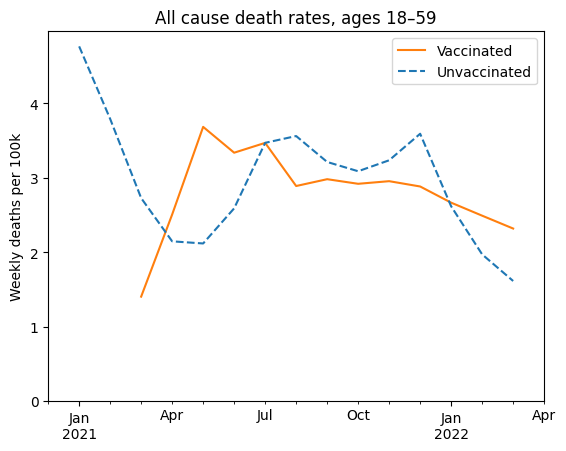

In [11]:
unvax_stat = ["Unvaccinated"]

vax_stat = [
    "Second dose, less than 21 days ago",
    "Second dose, at least 21 days ago",
    "Third dose or booster, less than 21 days ago",
    "Third dose or booster, at least 21 days ago",
]
# Unvaccinated
groups = ["18-39", "40-49", "50-59"]
seq = [table[group][unvax_stat] for group in groups]
t = pd.concat(seq, axis=1)
seq = [weight[group][unvax_stat] for group in groups]
w = pd.concat(seq, axis=1)
# make sure that weight is 0 where table is NaN
a = np.where(t.notna(), w, 0)
w = pd.DataFrame(a, index=w.index, columns=w.columns)
# normalize the weights rowwise
total = w.sum(axis=1)
weight_norm = w.divide(total, axis=0)
# compute the weighted sum of table
prod = t.fillna(0) * weight_norm
unvax = prod.sum(axis=1).replace(0, np.nan)

# Vaccinated
groups = ["18-39", "40-49", "50-59"]
seq = [table[group][vax_stat] for group in groups]
t = pd.concat(seq, axis=1)
seq = [weight[group][vax_stat] for group in groups]
w = pd.concat(seq, axis=1)
# make sure that weight is 0 where table is NaN
a = np.where(t.notna(), w, 0)
w = pd.DataFrame(a, index=w.index, columns=w.columns)
# normalize the weights rowwise
total = w.sum(axis=1)
weight_norm = w.divide(total, axis=0)
# compute the weighted sum of table
prod = t.fillna(0) * weight_norm
vax = prod.sum(axis=1).replace(0, np.nan)

vax.plot(color="C1", ls="-", label="Vaccinated")
unvax.plot(color="C0", ls="--", label="Unvaccinated", xlabel="", ylabel="Weekly deaths per 100k", title="All cause death rates, ages 18–59", ylim=[0.1, 4.6])

plt.legend(loc="upper right")

# set axes
high = max(max(unvax), max(vax))
start = pd.Timestamp("2020-12-15")
end = pd.Timestamp("2022-04-01")
ax = plt.gca()
ax.set(ylim=(0, high+0.2), xlim=(start, end))

Now, produce this plot for all separate age groups (best to use build a function...)!

***

### Exercise 2
In your own words, describe the Fundamental Problem of Causal Inference!


***

### Exercise 3
1. Describe the following 3 DAGs and their implications using e.g. "confounder", "collider", "backdoor path"!

<img src="https://github.com/firrm/DAI/blob/main/assets/confounder.png?raw=1" alt="Confounder" style="width: 350px;"/>
<img src="https://github.com/firrm/DAI/blob/main/assets/unobserved%20confounder.png?raw=1" alt="Unobserved Confounder" style="width: 350px;"/>
<img src="https://github.com/firrm/DAI/blob/main/assets/collider.png?raw=1" alt="Collider" style="width: 350px;"/>
<br>

2. The following DAG combines the variables female ($F$), discrimination ($D$), occupation ($O$), ability ($A$) and earnings ($Y$). Explain the researcher's model expressed by this DAG!

<img src="https://github.com/firrm/DAI/blob/main/assets/discrimination.png?raw=1" alt="Discrimination" style="width: 350px;"/>
<br>

3. Imagine now, we were not interested in the total effect of discrimination on earnings but wanted to control for occupation. Google, for example, claimed that once occupation is taken into account, gender discrimination disappeares (https://www.theverge.com/2022/6/12/23164678/google-pay-118-million-settle-gender-discrimination-lawsuit). What problem would arise if we controlled for occupation?

4. The following code generates data as suggested by the DAG (hard coded & borrowed from Scott Cunningham). Use this data to show how the discrimination effect apparently changes if we a) only look at the total effect of discrimination, b) control for occupation and thereby open a backdoor path, and c) close this backdoor path while still controlling for $O$.

5. In 2009 Megan Fox was voted the worst talented, but sexiest actress (https://www.reuters.com/article/idUSTRE5BR3J020091228/?type=entertainmentNews). How are talent and beauty related? Are they? Look at the code below (borrowed from Scott Cunningham & Gabriel Rossman)! Here, talent and beauty are independent, random draws from a standard normal distribution, assigned to 2500 individuals. Consider individuals whose combination (sum) of talent and beauty ranks in the top 85th percentile as moviestars! Show only these moviestars in a scatterplot (talent vs beauty)! Make a judgement regarding the association of talent and beauty! How does the sample selection influence your perception?
***


In [12]:
## task 4

import numpy as np
import pandas as pd
import statsmodels.api as sm
from stargazer.stargazer import Stargazer

tb = pd.DataFrame({
    'female': np.random.binomial(1, .5, size=10000),
    'ability': np.random.normal(size=10000)})
tb['discrimination'] = tb.female.copy()
tb['occupation'] = 1 + 2*tb['ability'] + 0*tb['female'] - 2*tb['discrimination'] + np.random.normal(size=10000)
tb['wage'] = 1 - 1*tb['discrimination'] + 1*tb['occupation'] + 2*tb['ability'] + np.random.normal(size=10000)


In [13]:
## task 5

import numpy as np
import pandas as pd
import plotnine as p
import statsmodels.api as sm

moviestar = pd.DataFrame({
    'beauty': np.random.normal(size=2500),
    'talent': np.random.normal(size=2500)})

moviestar['score'] = moviestar['beauty'] + moviestar['talent']


### References
***

[1] Cunningham, S. (2021). Causal Inference: The Mixtape. Yale University Press. https://doi.org/10.2307/j.ctv1c29t27

[2] Garreta, R., & Moncecchi, G. (2013). Learning scikit-learn: machine learning in python. Packt Publishing Ltd.

[3] Müller, A. C., & Guido, S. (2016). Introduction to machine learning with Python: a guide for data scientists. " O'Reilly Media, Inc.".

[4] Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., & Vanderplas, J. (2011). Scikit-learn: Machine learning in Python. the Journal of machine Learning research, 12, 2825-2830.
